# Photon-mosaic: a pipeline API for Calcium Imaging

This notebook demonstrates how to use photon-mosaic framework for use with calcium imaging data. We'll show how to:
- Load imaging data from TIFF files
- Explore and visualize the data
- Cache data for efficient processing
- Run Suite2P extraction on the imaging data

The core API is based on the SpikeInterface framework, which is widely used for extracellular electrophysiology data analysis. Photon-mosaic extends those concepts to calcium imaging workflows.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

import photon_mosaic as pm
import photon_mosaic.preprocessing as pmpre
import photon_mosaic.extractors as pme
import photon_mosaic.widgets as pmw
import photon_mosaic.segmentation as pms
%matplotlib widget

## Load Imaging Data

First, we'll load a TIFF file containing calcium imaging data. The `read_scan_image_tiff` function allows us to specify the channel and plane we want to extract.

In [2]:
# base_folder = Path("path-to-base-folder")
base_folder = Path("/Users/lauraporta/local_data/4new")

imaging = pme.read_tiff_imaging(file_path=base_folder / "M0_2017-10-13_004.tif", sampling_frequency=30)

## Inspect the Imaging Object

The imaging object provides a summary of the loaded data, similar to how SpikeInterface recording objects work.

In [3]:
imaging

TiffImaging (ROIExtractors) (TiffImaging):
30.0Hz - 1 segments - 662 rows x 788 columns  - 1.1min - int16 dtype - 1.9GiB

## Access Imaging Data

The imaging object supports lazy loading, allowing you to access specific frame ranges without loading the entire dataset into memory. This is particularly useful for large imaging sessions.

In [4]:
print(f"Number of frames {imaging.get_num_frames()}")
print(f"Image shape {imaging.image_shape}")
video_snippet = imaging.get_series(start_frame=0, end_frame=40) # demonstrating lazy access
print(f"Video snippet shape {video_snippet.shape}")

Number of frames 2000
Image shape [662 788]
Video snippet shape (40, 662, 788)


## Visualize the Average Image

We can compute and display the average image across a subset of chunks to get a sense of the field of view and visible structures.

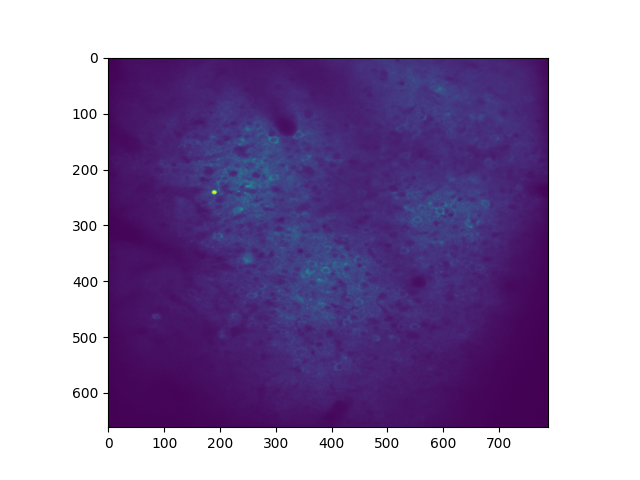

In [5]:
avg_image = imaging.get_average_image()
plt.figure()
plt.imshow(avg_image, vmax=8185)

## Run Suite2P Registration

Finally, we run Suite2P's segmentation and extraction pipeline on our cached imaging data.

In [7]:
registered = pmpre.register_suite2p(imaging)
registered_subset = registered.get_series(200, 250)
type(registered_subset)

numpy.memmap

In [8]:
pmw.plot_imaging_series(registered, backend="ipywidgets")